<a href="https://colab.research.google.com/github/Saransh-Basu-01/Understanding-Deep-learning-/blob/main/Deep_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

# Define the Rectified Linear Unit (ReLU) function
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation

In [3]:
def shallow_1_1_3(x, activation_fn, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31):
  # Initial lines
  pre_1 = theta_10 + theta_11 * x
  pre_2 = theta_20 + theta_21 * x
  pre_3 = theta_30 + theta_31 * x
  # Activation functions
  act_1 = activation_fn(pre_1)
  act_2 = activation_fn(pre_2)
  act_3 = activation_fn(pre_3)
  # Weight activations
  w_act_1 = phi_1 * act_1
  w_act_2 = phi_2 * act_2
  w_act_3 = phi_3 * act_3
  # Combine weighted activation and add y offset
  y = phi_0 + w_act_1 + w_act_2 + w_act_3
  # Return everything we have calculated
  return y

In [4]:
# # Plot two shallow neural networks and the composition of the two
def plot_neural_two_components(x_in, net1_out, net2_out, net12_out=None):

  # Plot the two networks separately
  fig, ax = plt.subplots(1,2)
  fig.set_size_inches(8.5, 8.5)
  fig.tight_layout(pad=3.0)
  ax[0].plot(x_in, net1_out,'r-')
  ax[0].set_xlabel('Net 1 input'); ax[0].set_ylabel('Net 1 output')
  ax[0].set_xlim([-1,1]);ax[0].set_ylim([-1,1])
  ax[0].set_aspect(1.0)
  ax[1].plot(x_in, net2_out,'b-')
  ax[1].set_xlabel('Net 2 input'); ax[1].set_ylabel('Net 2 output')
  ax[1].set_xlim([-1,1]);ax[1].set_ylim([-1,1])
  ax[1].set_aspect(1.0)
  plt.show()

  if net12_out is not None:
    # Plot their composition
    fig, ax = plt.subplots()
    ax.plot(x_in ,net12_out,'g-')
    ax.set_xlabel('Net 1 Input'); ax.set_ylabel('Net 2 Output')
    ax.set_xlim([-1,1]);ax.set_ylim([-1,1])
    ax.set_aspect(1.0)
    plt.show()

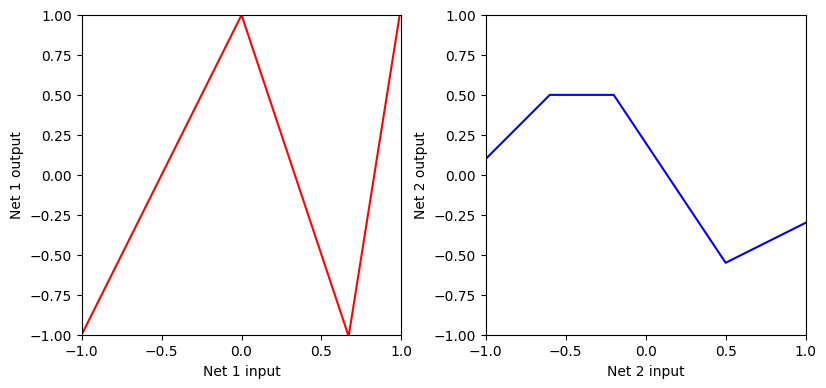

In [5]:
n1_theta_10 = 0.0   ; n1_theta_11 = -1.0
n1_theta_20 = 0     ; n1_theta_21 = 1.0
n1_theta_30 = -0.67 ; n1_theta_31 =  1.0
n1_phi_0 = 1.0; n1_phi_1 = -2.0; n1_phi_2 = -3.0; n1_phi_3 = 9.3

# Now lets define some parameters and run the second neural network
n2_theta_10 =  -0.6 ; n2_theta_11 = -1.0
n2_theta_20 =  0.2  ; n2_theta_21 = 1.0
n2_theta_30 =  -0.5  ; n2_theta_31 =  1.0
n2_phi_0 = 0.5; n2_phi_1 = -1.0; n2_phi_2 = -1.5; n2_phi_3 = 2.0

# Display the two inputs
x = np.arange(-1,1,0.001)
# We run the first  and second neural networks for each of these input values
net1_out = shallow_1_1_3(x, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
net2_out = shallow_1_1_3(x, ReLU, n2_phi_0, n2_phi_1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
# Plot both graphs
plot_neural_two_components(x, net1_out, net2_out)

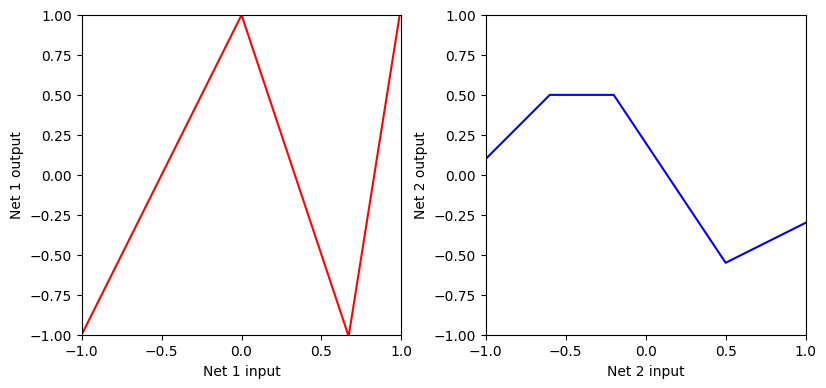

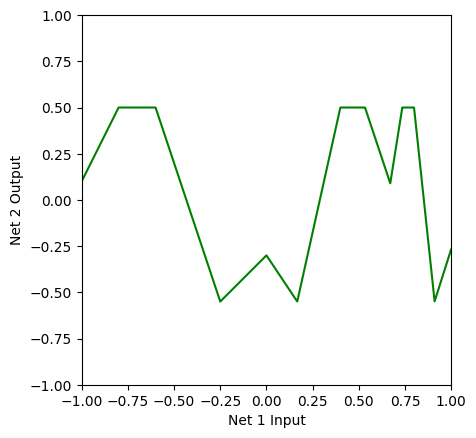

In [6]:

# Now let's see if your predictions were right

# TODO feed the output of first network into second network (replace this line)
net12_out = shallow_1_1_3(net1_out, ReLU,
                          n2_phi_0, n2_phi_1, n2_phi_2, n2_phi_3,
                          n2_theta_10, n2_theta_11,
                          n2_theta_20, n2_theta_21,
                          n2_theta_30, n2_theta_31)

# Plot all three graphs
plot_neural_two_components(x, net1_out, net2_out, net12_out)

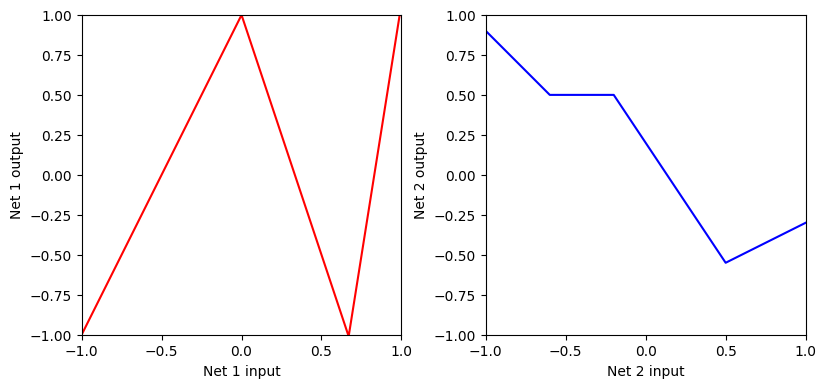

In [7]:

# Now we'll change things a up a bit.  What happens if we change the second network? (note the *-1 change)
net1_out = shallow_1_1_3(x, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
net2_out = shallow_1_1_3(x, ReLU, n2_phi_0, n2_phi_1*-1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
plot_neural_two_components(x, net1_out, net2_out)

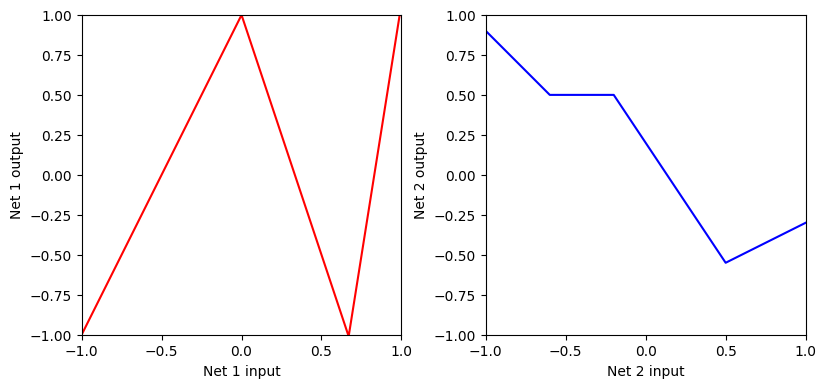

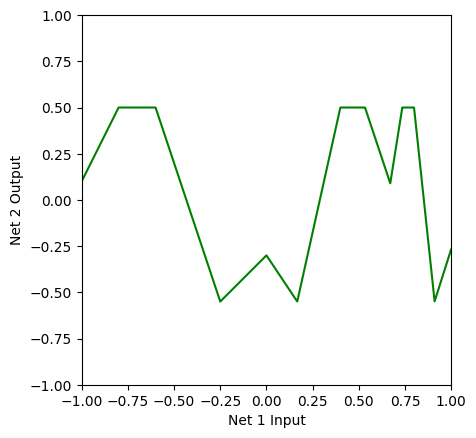

In [8]:

# When you have a prediction, run this code to see if you were right
net12_out = shallow_1_1_3(net1_out, ReLU, n2_phi_0, n2_phi_1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
plot_neural_two_components(x, net1_out, net2_out, net12_out)

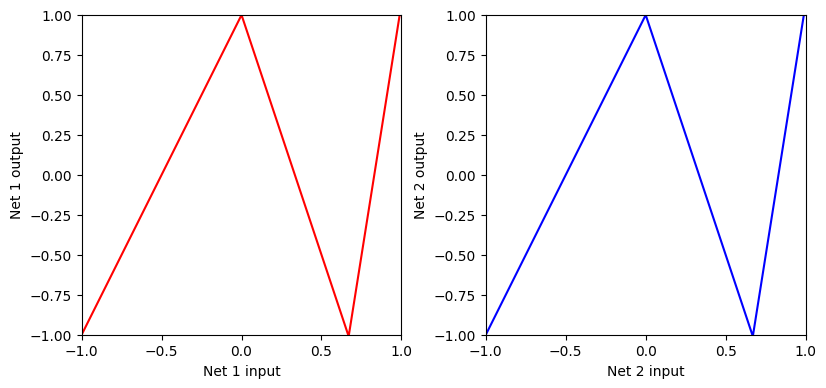

In [9]:

# Let's change things again.  What happens if the first network and second networks are the same?
net1_out = shallow_1_1_3(x, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
net2_out_new = shallow_1_1_3(x, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
plot_neural_two_components(x, net1_out, net2_out_new)

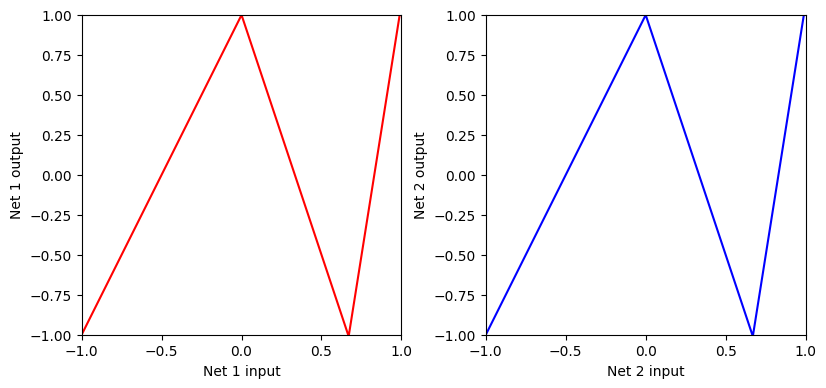

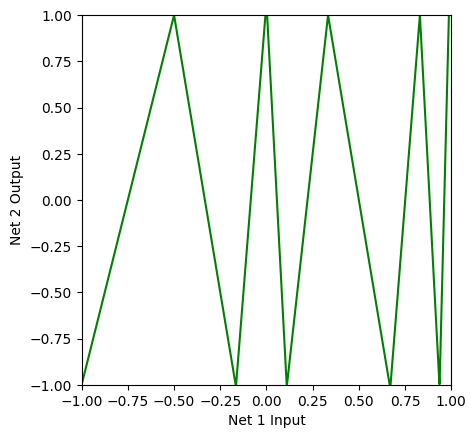

In [10]:

# When you have a prediction, run this code to see if you were right
net12_out = shallow_1_1_3(net1_out, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
plot_neural_two_components(x, net1_out, net2_out_new, net12_out)

In [11]:
def shallow_1_1_3_3(x, activation_fn, phi, psi, theta):

    # ============================================
    # LAYER 1: First hidden layer (3 units)
    # Equation 4.7: h_j = activation(θ_j0 + θ_j1 * x)
    # ============================================

    # theta[0][0] = θ₁₀, theta[0][1] = θ₁₁
    layer1_pre_1 = theta[0][0] + theta[0][1] * x
    layer1_pre_2 = theta[1][0] + theta[1][1] * x
    layer1_pre_3 = theta[2][0] + theta[2][1] * x

    # Apply activation function (ReLU)
    h1 = activation_fn(layer1_pre_1)
    h2 = activation_fn(layer1_pre_2)
    h3 = activation_fn(layer1_pre_3)


    # ============================================
    # LAYER 2: Second hidden layer (3 units)
    # Equation 4.8: h'_k = activation(ψ_k0 + ψ_k1*h1 + ψ_k2*h2 + ψ_k3*h3)
    # ============================================

    # ψ[0][0] = ψ₁₀ (bias), ψ[0][1] = ψ₁₁, ψ[0][2] = ψ₁₂, ψ[0][3] = ψ₁₃
    layer2_pre_1 = psi[0][0] + psi[0][1]*h1 + psi[0][2]*h2 + psi[0][3]*h3
    layer2_pre_2 = psi[1][0] + psi[1][1]*h1 + psi[1][2]*h2 + psi[1][3]*h3
    layer2_pre_3 = psi[2][0] + psi[2][1]*h1 + psi[2][2]*h2 + psi[2][3]*h3

    # Apply activation function (ReLU)
    h1_prime = activation_fn(layer2_pre_1)
    h2_prime = activation_fn(layer2_pre_2)
    h3_prime = activation_fn(layer2_pre_3)


    # ============================================
    # OUTPUT LAYER
    # Equation 4.9: y = φ₀ + φ₁*h'_1 + φ₂*h'_2 + φ₃*h'_3
    # ============================================

    # Weighted outputs by phi
    phi1_h1_prime = phi[1] * h1_prime  # φ₁ * h'₁
    phi2_h2_prime = phi[2] * h2_prime  # φ₂ * h'₂
    phi3_h3_prime = phi[3] * h3_prime  # φ₃ * h'₃

    # Combine: y = φ₀ + φ₁*h'₁ + φ₂*h'₂ + φ₃*h'₃
    y = phi[0] + phi1_h1_prime + phi2_h2_prime + phi3_h3_prime


    # Return everything
    return y, layer2_pre_1, layer2_pre_2, layer2_pre_3, h1_prime, h2_prime, h3_prime, phi1_h1_prime, phi2_h2_prime, phi3_h3_prime

In [12]:
# # Plot two layer neural network as in figure 4.5
def plot_neural_two_layers(x, y, layer2_pre_1, layer2_pre_2, layer2_pre_3, h1_prime, h2_prime, h3_prime, phi1_h1_prime, phi2_h2_prime, phi3_h3_prime):

    fig, ax = plt.subplots(3,3)
    fig.set_size_inches(8.5, 8.5)
    fig.tight_layout(pad=3.0)
    ax[0,0].plot(x,layer2_pre_1,'r-'); ax[0,0].set_ylabel(r'')
    ax[0,1].plot(x,layer2_pre_2,'b-'); ax[0,1].set_ylabel(r'')
    ax[0,2].plot(x,layer2_pre_3,'g-'); ax[0,2].set_ylabel(r'')
    ax[1,0].plot(x,h1_prime,'r-'); ax[1,0].set_ylabel(r"")
    ax[1,1].plot(x,h2_prime,'b-'); ax[1,1].set_ylabel(r"")
    ax[1,2].plot(x,h3_prime,'g-'); ax[1,2].set_ylabel(r"")
    ax[2,0].plot(x,phi1_h1_prime,'r-'); ax[2,0].set_ylabel(r"")
    ax[2,1].plot(x,phi2_h2_prime,'b-'); ax[2,1].set_ylabel(r"")
    ax[2,2].plot(x,phi3_h3_prime,'g-'); ax[2,2].set_ylabel(r"")

    for plot_y in range(3):
      for plot_x in range(3):
        ax[plot_y,plot_x].set_xlim([0,1]);ax[plot_x,plot_y].set_ylim([-1,1])
        ax[plot_y,plot_x].set_aspect(0.5)
      ax[2,plot_y].set_xlabel(r'Input, x');
    plt.show()

    fig, ax = plt.subplots()
    ax.plot(x,y)
    ax.set_xlabel(r'Input, x'); ax.set_ylabel(r'Output, y')
    ax.set_xlim([0,1]);ax.set_ylim([-1,1])
    ax.set_aspect(0.5)
    plt.show()

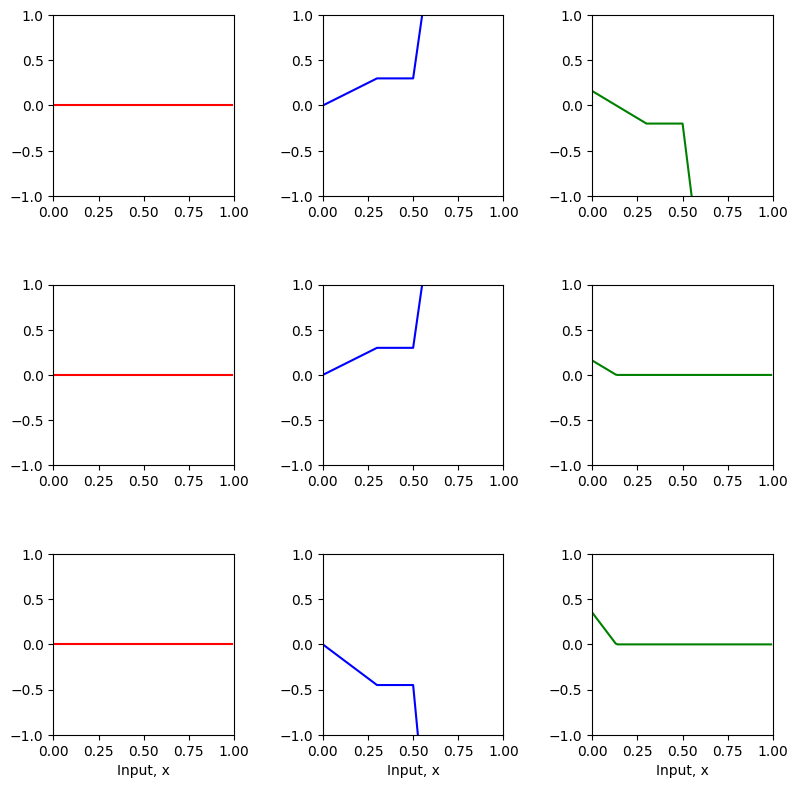

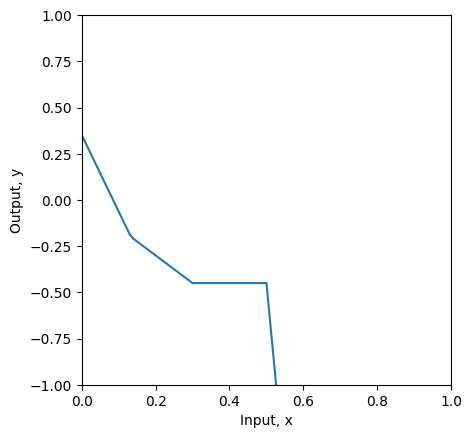

In [13]:
theta = np.zeros([4,2])
psi = np.zeros([4,4])
phi = np.zeros([4,1])

theta[1,0] =  0.3 ; theta[1,1] = -1.0
theta[2,0]= -1.0  ; theta[2,1] = 2.0
theta[3,0] = -0.5  ; theta[3,1] = 0.65
psi[1,0] = 0.3;  psi[1,1] = 2.0; psi[1,2] = -1.0; psi[1,3]=7.0
psi[2,0] = -0.2;  psi[2,1] = 2.0; psi[2,2] = 1.2; psi[2,3]=-8.0
psi[3,0] = 0.3;  psi[3,1] = -2.3; psi[3,2] = -0.8; psi[3,3]=2.0
phi[0] = 0.0; phi[1] = 0.5; phi[2] = -1.5; phi [3] = 2.2

# Define a range of input values
x = np.arange(0,1,0.01)

# Run the neural network
y, layer2_pre_1, layer2_pre_2, layer2_pre_3, h1_prime, h2_prime, h3_prime, phi1_h1_prime, phi2_h2_prime, phi3_h3_prime \
    = shallow_1_1_3_3(x, ReLU, phi, psi, theta)

# And then plot it
plot_neural_two_layers(x, y, layer2_pre_1, layer2_pre_2, layer2_pre_3, h1_prime, h2_prime, h3_prime, phi1_h1_prime, phi2_h2_prime, phi3_h3_prime)


In [14]:
def shallow_1_1_3(x, activation_fn, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31):
  # Initial lines
  pre_1 = theta_10 + theta_11 * x
  pre_2 = theta_20 + theta_21 * x
  pre_3 = theta_30 + theta_31 * x
  # Activation functions
  act_1 = activation_fn(pre_1)
  act_2 = activation_fn(pre_2)
  act_3 = activation_fn(pre_3)
  # Weight activations
  w_act_1 = phi_1 * act_1
  w_act_2 = phi_2 * act_2
  w_act_3 = phi_3 * act_3
  # Combine weighted activation and add y offset
  y = phi_0 + w_act_1 + w_act_2 + w_act_3
  # Return everything we have calculated
  return y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3

In [15]:

# # Plot the shallow neural network.  We'll assume input in is range [-1,1] and output [-1,1]
def plot_neural(x, y):
  fig, ax = plt.subplots()
  ax.plot(x.T,y.T)
  ax.set_xlabel('Input'); ax.set_ylabel('Output')
  ax.set_xlim([-1,1]);ax.set_ylim([-1,1])
  ax.set_aspect(1.0)
  plt.show()

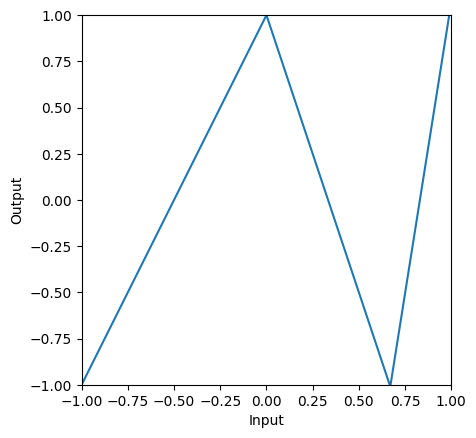

In [16]:
n1_theta_10 = 0.0   ; n1_theta_11 = -1.0
n1_theta_20 = 0     ; n1_theta_21 = 1.0
n1_theta_30 = -0.67 ; n1_theta_31 =  1.0
n1_phi_0 = 1.0; n1_phi_1 = -2.0; n1_phi_2 = -3.0; n1_phi_3 = 9.3

# Define a range of input values
n1_in = np.arange(-1,1,0.01).reshape([1,-1])

# We run the neural network for each of these input values
n1_out, *_ = shallow_1_1_3(n1_in, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
# And then plot it
plot_neural(n1_in, n1_out)


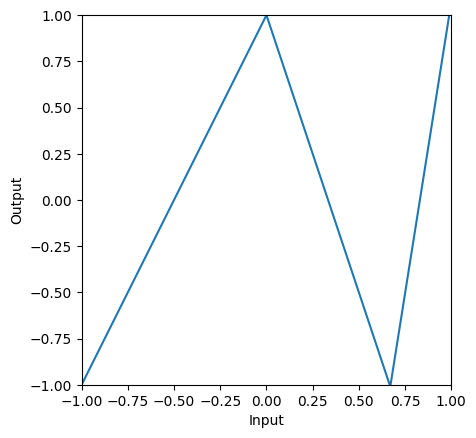

In [17]:
beta_0 = np.zeros((3,1))
Omega_0 = np.zeros((3,1))
beta_1 = np.zeros((1,1))
Omega_1 = np.zeros((1,3))

# Layer 1 (theta parameters)
beta_0[0,0] = n1_theta_10   # 0.0
Omega_0[0,0] = n1_theta_11  # -1.0

beta_0[1,0] = n1_theta_20   # 0
Omega_0[1,0] = n1_theta_21  # 1.0

beta_0[2,0] = n1_theta_30   # -0.67
Omega_0[2,0] = n1_theta_31  # 1.0

# Output layer (phi parameters)
beta_1[0,0] = n1_phi_0      # 1.0

Omega_1[0,0] = n1_phi_1     # -2.0
Omega_1[0,1] = n1_phi_2     # -3.0
Omega_1[0,2] = n1_phi_3     # 9.3

# Forward pass
n_data = n1_in.size
n_dim_in = 1
n1_in_mat = np.reshape(n1_in, (n_dim_in, n_data))

h1 = ReLU(beta_0 + np.matmul(Omega_0, n1_in_mat))
n1_out = beta_1 + np.matmul(Omega_1, h1)

# Plot to verify
plot_neural(n1_in, n1_out)

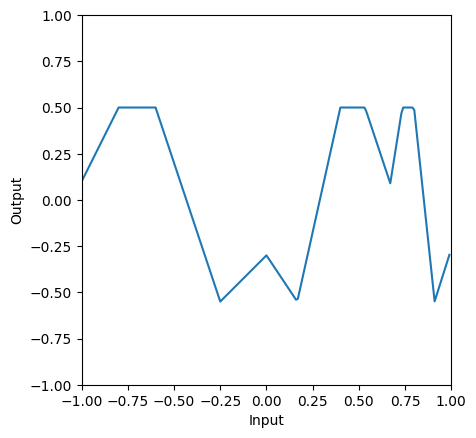

In [18]:
# Now lets define some parameters and run the second neural network
n2_theta_10 =  -0.6 ; n2_theta_11 = -1.0
n2_theta_20 =  0.2  ; n2_theta_21 = 1.0
n2_theta_30 =  -0.5  ; n2_theta_31 =  1.0
n2_phi_0 = 0.5; n2_phi_1 = -1.0; n2_phi_2 = -1.5; n2_phi_3 = 2.0

# Define a range of input values
n2_in = np.arange(-1,1,0.01)

# We run the second neural network on the output of the first network
n2_out, *_ = \
    shallow_1_1_3(n1_out, ReLU, n2_phi_0, n2_phi_1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
# And then plot it
plot_neural(n1_in, n2_out)


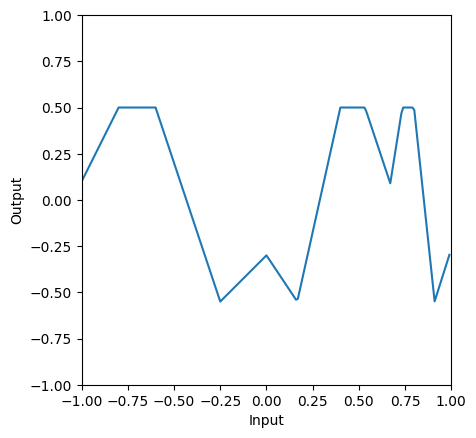

In [19]:
beta_0 = np.zeros((3,1))    # Bias for layer 1 (3x1)
Omega_0 = np.zeros((3,1))   # Weights for layer 1 (3x1)
beta_1 = np.zeros((3,1))    # Bias for layer 2 (3x1)
Omega_1 = np.zeros((3,3))   # Weights for layer 2 (3x3)
beta_2 = np.zeros((1,1))    # Bias for output layer (1x1)
Omega_2 = np.zeros((1,3))   # Weights for output layer (1x3)

# ============================================
# LAYER 1: Network 1's hidden layer (theta)
# h1 = ReLU(β₀ + Ω₀ × x)
# ============================================

# Unit 1: h₁ = ReLU(θ₁₀ + θ₁₁ × x)
beta_0[0,0] = n1_theta_10    # θ₁₀ = 0.0
Omega_0[0,0] = n1_theta_11   # θ₁₁ = -1.0

# Unit 2: h₂ = ReLU(θ₂₀ + θ₂₁ × x)
beta_0[1,0] = n1_theta_20    # θ₂₀ = 0
Omega_0[1,0] = n1_theta_21   # θ₂₁ = 1.0

# Unit 3: h₃ = ReLU(θ₃₀ + θ₃₁ × x)
beta_0[2,0] = n1_theta_30    # θ₃₀ = -0.67
Omega_0[2,0] = n1_theta_31   # θ₃₁ = 1.0


# ============================================
# LAYER 2: Network 2's hidden layer composed with Network 1
# This is the KEY insight!
# h2 = ReLU(β₁ + Ω₁ × h1)
#
# Network 2's hidden units normally would be:
# h'_k = ReLU(ψ_k0 + ψ_k1 × z) for a single input z
#
# But here z = Net1(x) = φ₀ + φ₁×h₁ + φ₂×h₂ + φ₃×h₃
# So we substitute!
# ============================================

# Let's derive the formulas:
#
# For Network 2, each hidden unit normally is:
# h'_1 = ReLU(ψ₁₀ + ψ₁₁ × z)
# h'_2 = ReLU(ψ₂₀ + ψ₂₁ × z)
# h'_3 = ReLU(ψ₃₀ + ψ₃₁ × z)
#
# Where z = φ₀ + φ₁×h₁ + φ₂×h₂ + φ₃×h₃
#
# Substituting z:
# h'_1 = ReLU(ψ₁₀ + ψ₁₁×(φ₀ + φ₁×h₁ + φ₂×h₂ + φ₃×h₃))
#      = ReLU(ψ₁₀ + ψ₁₁×φ₀ + ψ₁₁×φ₁×h₁ + ψ₁₁×φ₂×h₂ + ψ₁₁×φ₃×h₃)
#
# So β₁[0,0] = ψ₁₀ + ψ₁₁×φ₀
#    Ω₁[0,0] = ψ₁₁×φ₁
#    Ω₁[0,1] = ψ₁₁×φ₂
#    Ω₁[0,2] = ψ₁₁×φ₃

# Unit 1 of layer 2: h'_1
beta_1[0,0] = n2_theta_10 + n2_theta_11 * n1_phi_0    # ψ₁₀ + ψ₁₁×φ₀
Omega_1[0,0] = n2_theta_11 * n1_phi_1                  # ψ₁₁×φ₁
Omega_1[0,1] = n2_theta_11 * n1_phi_2                  # ψ₁₁×φ₂
Omega_1[0,2] = n2_theta_11 * n1_phi_3                  # ψ₁₁×φ₃

# Unit 2 of layer 2: h'_2
# h'_2 = ReLU(ψ₂₀ + ψ₂₁×z) = ReLU(ψ₂₀ + ψ₂₁×(φ₀ + φ₁×h₁ + φ₂×h₂ + φ₃×h₃))
beta_1[1,0] = n2_theta_20 + n2_theta_21 * n1_phi_0    # ψ₂₀ + ψ₂₁×φ₀
Omega_1[1,0] = n2_theta_21 * n1_phi_1                  # ψ₂₁×φ₁
Omega_1[1,1] = n2_theta_21 * n1_phi_2                  # ψ₂₁×φ₂
Omega_1[1,2] = n2_theta_21 * n1_phi_3                  # ψ₂₁×φ₃

# Unit 3 of layer 2: h'_3
# h'_3 = ReLU(ψ₃₀ + ψ₃₁×z) = ReLU(ψ₃₀ + ψ₃₁×(φ₀ + φ₁×h₁ + φ₂×h₂ + φ₃×h₃))
beta_1[2,0] = n2_theta_30 + n2_theta_31 * n1_phi_0    # ψ₃₀ + ψ₃₁×φ₀
Omega_1[2,0] = n2_theta_31 * n1_phi_1                  # ψ₃₁×φ₁
Omega_1[2,1] = n2_theta_31 * n1_phi_2                  # ψ₃₁×φ₂
Omega_1[2,2] = n2_theta_31 * n1_phi_3                  # ψ₃₁×φ₃


# ============================================
# LAYER 3: Output layer (Network 2's output)
# y = β₂ + Ω₂ × h2
# ============================================

# Network 2's output normally is:
# y = φ'_0 + φ'_1×h'_1 + φ'_2×h'_2 + φ'_3×h'_3
#
# So β₂[0,0] = φ'_0 = n2_phi_0
#    Ω₂[0,0] = φ'_1 = n2_phi_1
#    Ω₂[0,1] = φ'_2 = n2_phi_2
#    Ω₂[0,2] = φ'_3 = n2_phi_3

beta_2[0,0] = n2_phi_0       # φ'_0 = 0.5
Omega_2[0,0] = n2_phi_1      # φ'_1 = -1.0
Omega_2[0,1] = n2_phi_2      # φ'_2 = -1.5
Omega_2[0,2] = n2_phi_3      # φ'_3 = 2.0


# ============================================
# FORWARD PASS
# ============================================

n_data = n1_in.size
n_dim_in = 1
n1_in_mat = np.reshape(n1_in, (n_dim_in, n_data))

# Layer 1: h1 = ReLU(β₀ + Ω₀ × x)
h1 = ReLU(beta_0 + np.matmul(Omega_0, n1_in_mat))

# Layer 2: h2 = ReLU(β₁ + Ω₁ × h1)
h2 = ReLU(beta_1 + np.matmul(Omega_1, h1))

# Layer 3: y = β₂ + Ω₂ × h2
n1_out = beta_2 + np.matmul(Omega_2, h2)

# Plot to verify
plot_neural(n1_in, n1_out)